# Evaluación Sumativa Unidad 02: Inferencia Estadística y Diagnóstico Paramétrico (ABP)

**Universidad Nacional de Loja**  
**Carrera:** Computación  
**Facultad:** Energía, Industrias y Recursos Naturales no Renovables  
**Asignatura:** Análisis de Teoría de la Distribución y Probabilidad  
**Estudiante:** Joaquín Emilio Moscol Castillo  
**Paralelo:** 2.º “A”  
**Docente:** Ing. Cristian Narváez G. Mg. Sc.  
**Dataset:** ENEMDU Vivienda y Hogar 2026-02  
**Región de análisis:** Provincia de Loja

## Aclaración sobre la numeración real de los APE

En la plataforma constan únicamente los siguientes APE de la Unidad 2:

- **APE06:** Distribuciones Continuas Notables.
- **APE07:** Distribuciones Muestrales y Teorema del Límite Central (TLC).
- **APE08:** Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student).
- **APE09:** Inferencia Estadística: Pruebas de Hipótesis Paramétricas (Z y T) y Análisis del Valor-p.
- **APE10:** Inferencia Estadística Multigrupo: ANOVA de un factor y pruebas Post-Hoc de Tukey.

Por esta razón, este cuaderno final integra **APE06 a APE10**. No se incluye APE11 porque no aparece como actividad subida en la plataforma.

## 1. Planteamiento del problema

El propósito del análisis es aplicar inferencia estadística paramétrica sobre datos reales de la provincia de Loja, utilizando la base ENEMDU de vivienda y hogar. La variable cuantitativa principal será **`vi141`**, interpretada como el valor mensual de arriendo o valor que el hogar paga/pagaría por la vivienda.

La investigación se desarrolla en tres niveles:

1. Diagnóstico de forma de la distribución: normalidad, asimetría y curtosis.
2. Estimación de parámetros: media e intervalo de confianza.
3. Contraste inferencial: prueba T unimuestral, comparación A/B y ANOVA con Tukey.

In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_1samp, ttest_ind, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# ============================================================
# 2. Carga robusta del dataset
# ============================================================

posibles_archivos = [
    'enemdu_vivienda_hogar_2026_02.csv',
    'enemdu_vivienda_hogar_2026_02(1).csv',
    '../Datos/enemdu_vivienda_hogar_2026_02.csv'
]

archivo_dataset = None
for archivo in posibles_archivos:
    if os.path.exists(archivo):
        archivo_dataset = archivo
        break

if archivo_dataset is None:
    raise FileNotFoundError('No se encontró el dataset. Sube el CSV al mismo entorno del notebook.')

# El archivo ENEMDU está separado por punto y coma.
df = pd.read_csv(archivo_dataset, sep=';', low_memory=False)

print(f'Dataset cargado: {archivo_dataset}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head()

Dataset cargado: enemdu_vivienda_hogar_2026_02.csv
Filas: 8765 | Columnas: 56


,area,ciudad,conglomerado,panelm,vivienda,hogar,vi01,vi02,vi03a,vi03b,vi04a,vi04b,vi05a,vi05b,vi06,vi07,vi07a,vi07b,vi08,vi09,vi09a,vi09b,vi10,vi101,vi102,vi10a,vi11,vi12,vi13,vi14,vi141,vi142,vi143,vi144,vi1511,vi1521,vi1512,vi1522,vi1531,vi1541,vi1532,vi1542,vi1533,vi1543,vi1534,vi1544,vi1535,vi1545,vi1536,vi1546,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1601,63,1,1,3,2,1,2,1,1,1,1,4,3,0,1,1,1,,,1,,,1,1,1,2,4,150,,,,2,,2,,,,,,,,,,,,,,2713,"108,768769522905",10150001601,1015000160106301,10150001601063011,202602
1,1,10150,1601,63,2,1,3,1,4,3,5,2,3,2,3,3,0,1,1,5,2,,1,,,2,3,1,2,5,80,,,,2,,2,,,,,,,,,,,,,,2713,"108,768769522905",10150001601,1015000160106302,10150001601063021,202602
2,1,10150,1601,63,3,1,3,1,2,1,1,2,1,1,4,3,0,1,1,1,,,1,,,1,1,1,2,4,250,,,,1,1,2,,2,,2,,2,,1,60,2,,2,,2713,"108,768769522905",10150001601,1015000160106303,10150001601063031,202602
3,1,10150,1601,63,4,1,1,1,4,2,5,2,3,2,3,2,0,1,1,1,,,1,,,1,2,1,2,4,100,,,,2,,2,,,,,,,,,,,,,,2713,"108,768769522905",10150001601,1015000160106304,10150001601063041,202602
4,1,10150,1601,63,5,1,3,1,2,1,2,1,1,1,4,3,0,1,1,1,,,1,,,1,1,1,2,4,120,,,,1,1,2,,2,,2,,2,,1,25,2,,2,,2713,"108,768769522905",10150001601,1015000160106305,10150001601063051,202602


## 2. Filtrado regional: provincia de Loja

En el dataset, la variable **`ciudad`** contiene el código territorial. Para trabajar únicamente con la provincia de Loja, se extraen los dos primeros dígitos del código, donde **11** corresponde a Loja.

In [3]:
# ============================================================
# 3. Filtrado de Loja y limpieza de variables principales
# ============================================================

df['provincia'] = df['ciudad'].astype(str).str.zfill(6).str[:2]
loja = df[df['provincia'] == '11'].copy()

columnas_numericas = ['area', 'vi05a', 'vi06', 'vi07', 'vi14', 'vi141']
for col in columnas_numericas:
    loja[col] = pd.to_numeric(loja[col], errors='coerce')

# Variable cuantitativa estratégica: valor mensual de arriendo o gasto de vivienda.
# Se excluyen valores faltantes, cero o códigos de no información si existieran.
loja = loja[(loja['vi141'].notna()) & (loja['vi141'] > 0) & (loja['vi141'] < 999999)].copy()

loja['area_etiqueta'] = loja['area'].map({1: 'Urbana', 2: 'Rural'}).fillna('No especificado')

# Agrupación para ANOVA: número total de cuartos de la vivienda.
loja['grupo_cuartos'] = np.select(
    [loja['vi06'] <= 2, loja['vi06'].between(3, 4), loja['vi06'] >= 5],
    ['1-2 cuartos', '3-4 cuartos', '5 o más cuartos'],
    default='No clasificado'
)

print(f'Registros de Loja después de limpieza: {len(loja)}')
loja[['ciudad', 'provincia', 'area_etiqueta', 'vi05a', 'vi06', 'vi07', 'vi141', 'grupo_cuartos']].head()

Registros de Loja después de limpieza: 302


,ciudad,provincia,area_etiqueta,vi05a,vi06,vi07,vi141,grupo_cuartos
4568,110150,11,Urbana,1,3,2,200,3-4 cuartos
4569,110150,11,Urbana,1,3,2,200,3-4 cuartos
4570,110150,11,Urbana,1,3,2,160,3-4 cuartos
4571,110150,11,Urbana,1,5,4,200,5 o más cuartos
4572,110150,11,Urbana,1,5,4,250,5 o más cuartos


## 3. Estadística descriptiva inicial

Antes de realizar pruebas paramétricas, se resumen los datos para conocer la media, mediana, desviación estándar y rango de la variable de análisis.

In [4]:
# ============================================================
# 4. Descripción de la variable vi141
# ============================================================

resumen_general = loja['vi141'].describe().to_frame(name='vi141')
resumen_general.loc['asimetria'] = loja['vi141'].skew()
resumen_general.loc['curtosis'] = loja['vi141'].kurtosis()
resumen_general

,vi141
count,302.0000
mean,142.7980
std,94.0826
min,20.0000
25%,80.0000
50%,120.0000
75%,200.0000
max,700.0000
asimetria,1.8357
curtosis,6.1235


In [5]:
# Tabla por área urbana/rural
resumen_area = loja.groupby('area_etiqueta')['vi141'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
resumen_area

,count,mean,std,median,min,max
area_etiqueta,,,,,,
Rural,136,94.6324,52.0101,100.0000,20,250
Urbana,166,182.2590,102.2513,160.0000,20,700


## 4. APE06: diagnóstico de normalidad

El análisis de normalidad permite comprobar si la variable puede aproximarse a una distribución normal. Se emplean tres criterios:

- Histograma de frecuencias.
- Gráfico Q-Q.
- Indicadores de asimetría, curtosis y prueba de Shapiro-Wilk.

Aunque una variable no sea perfectamente normal, cuando el tamaño muestral es suficientemente grande, el Teorema del Límite Central permite trabajar con la distribución de la media muestral bajo criterios paramétricos.

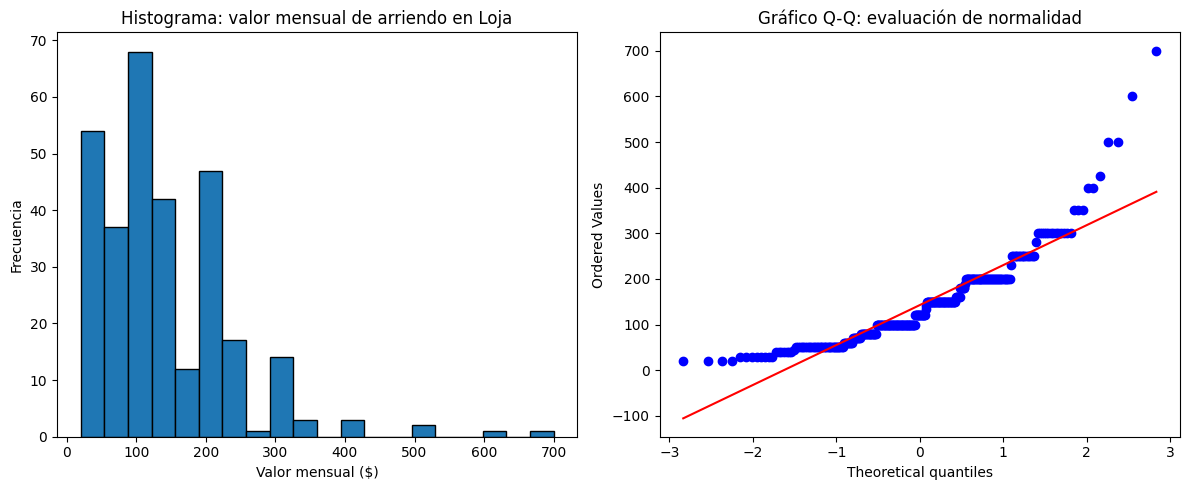

Asimetría: 1.8357
Curtosis: 6.1235
Shapiro-Wilk: estadístico=0.8580, valor-p=5.2607e-16


In [6]:
# ============================================================
# 5. Histograma y gráfico Q-Q
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(loja['vi141'], bins=20, edgecolor='black')
axes[0].set_title('Histograma: valor mensual de arriendo en Loja')
axes[0].set_xlabel('Valor mensual ($)')
axes[0].set_ylabel('Frecuencia')

stats.probplot(loja['vi141'], dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q: evaluación de normalidad')

plt.tight_layout()
plt.show()

asimetria = loja['vi141'].skew()
curtosis = loja['vi141'].kurtosis()
shapiro_stat, shapiro_p = stats.shapiro(loja['vi141'])

print(f'Asimetría: {asimetria:.4f}')
print(f'Curtosis: {curtosis:.4f}')
print(f'Shapiro-Wilk: estadístico={shapiro_stat:.4f}, valor-p={shapiro_p:.4e}')

### Interpretación del diagnóstico de normalidad

La variable **`vi141`** presenta asimetría positiva y curtosis alta, lo que indica una distribución sesgada hacia la derecha con presencia de valores altos. El valor-p de Shapiro-Wilk es menor que 0,05; por tanto, se rechaza la normalidad estricta de los datos brutos.

Sin embargo, el tamaño muestral regional es mayor que 30. Por ello, para inferir sobre la media poblacional se aplica el fundamento del **APE07: Teorema del Límite Central**, que indica que la distribución de las medias muestrales tiende a aproximarse a una normal cuando el tamaño de muestra es suficientemente grande.

## 5. APE08: estimación de parámetros e intervalo de confianza

Se calcula un intervalo de confianza del 95% para la media poblacional del valor mensual de arriendo en Loja.

Como la desviación estándar poblacional no es conocida, se utiliza la distribución **T de Student**:

$$
IC = \bar{x} \pm t_{\alpha/2, n-1}\left(\frac{s}{\sqrt{n}}\right)
$$

In [7]:
# ============================================================
# 6. Intervalo de confianza para la media
# ============================================================

n = loja['vi141'].count()
media = loja['vi141'].mean()
desv = loja['vi141'].std(ddof=1)
error_estandar = desv / np.sqrt(n)
t_critico = stats.t.ppf(0.975, df=n-1)
limite_inferior = media - t_critico * error_estandar
limite_superior = media + t_critico * error_estandar

print(f'n = {n}')
print(f'Media muestral = {media:.2f}')
print(f'Desviación estándar muestral = {desv:.2f}')
print(f'Error estándar = {error_estandar:.2f}')
print(f't crítico 95% = {t_critico:.4f}')
print(f'IC 95% para la media = [{limite_inferior:.2f}, {limite_superior:.2f}]')

n = 302
Media muestral = 142.80
Desviación estándar muestral = 94.08
Error estándar = 5.41
t crítico 95% = 1.9679
IC 95% para la media = [132.14, 153.45]


### Interpretación del intervalo

Con un 95% de confianza, la media poblacional del valor mensual de arriendo en los hogares de Loja se ubica dentro del intervalo estimado. Este intervalo representa un rango plausible para el parámetro poblacional, no solamente un valor puntual.

## 6. APE09: prueba de hipótesis paramétrica unimuestral

Se plantea una afirmación razonable: **el valor promedio mensual de arriendo en Loja es de 200 dólares**.

### Hipótesis

$$H_0: \mu = 200$$

$$H_1: \mu \neq 200$$

Nivel de significancia:

$$\alpha = 0.05$$

Se aplica una **prueba T de Student para una muestra**, porque se desconoce la desviación estándar poblacional y se trabaja con la desviación estándar muestral.

In [8]:
# ============================================================
# 7. Prueba T unimuestral
# ============================================================

mu_0 = 200
alpha = 0.05
resultado_t = ttest_1samp(loja['vi141'], popmean=mu_0)

print(f'H0: mu = {mu_0}')
print(f'H1: mu != {mu_0}')
print(f'Estadístico t = {resultado_t.statistic:.4f}')
print(f'Grados de libertad = {resultado_t.df}')
print(f'Valor-p = {resultado_t.pvalue:.4e}')

if resultado_t.pvalue < alpha:
    print('Decisión: se rechaza H0.')
else:
    print('Decisión: no se rechaza H0.')

H0: mu = 200
H1: mu != 200
Estadístico t = -10.5659
Grados de libertad = 301
Valor-p = 2.1064e-22
Decisión: se rechaza H0.


### Interpretación del valor-p

El valor-p representa la probabilidad de obtener una media muestral tan extrema como la observada, suponiendo que la hipótesis nula fuera verdadera. Como el valor-p obtenido es menor que 0,05, se rechaza la hipótesis nula. En consecuencia, existe evidencia estadística suficiente para afirmar que el valor promedio mensual de arriendo en Loja es diferente de 200 dólares.

## 7. Comparación A/B: área urbana vs área rural

Como análisis complementario, se divide el dataset regional en dos grupos:

- **Grupo A:** hogares del área urbana.
- **Grupo B:** hogares del área rural.

Se aplica una prueba T de Welch para dos muestras independientes, ya que las varianzas de ambos grupos no necesariamente son iguales.

### Hipótesis

$$H_0: \mu_{urbana} = \mu_{rural}$$

$$H_1: \mu_{urbana} \neq \mu_{rural}$$

In [9]:
# ============================================================
# 8. A/B Testing: urbano vs rural
# ============================================================

urbana = loja.loc[loja['area'] == 1, 'vi141']
rural = loja.loc[loja['area'] == 2, 'vi141']

print('Resumen por área:')
display(loja.groupby('area_etiqueta')['vi141'].agg(['count', 'mean', 'std', 'median']))

resultado_ab = ttest_ind(urbana, rural, equal_var=False)

print(f'Estadístico t de Welch = {resultado_ab.statistic:.4f}')
print(f'Valor-p = {resultado_ab.pvalue:.4e}')

if resultado_ab.pvalue < alpha:
    print('Decisión: se rechaza H0. Existe diferencia significativa entre área urbana y rural.')
else:
    print('Decisión: no se rechaza H0. No existe evidencia suficiente de diferencia.')

Resumen por área:


,count,mean,std,median
area_etiqueta,,,,
Rural,136,94.6324,52.0101,100.0000
Urbana,166,182.2590,102.2513,160.0000


Estadístico t de Welch = 9.6256
Valor-p = 6.6426e-19
Decisión: se rechaza H0. Existe diferencia significativa entre área urbana y rural.


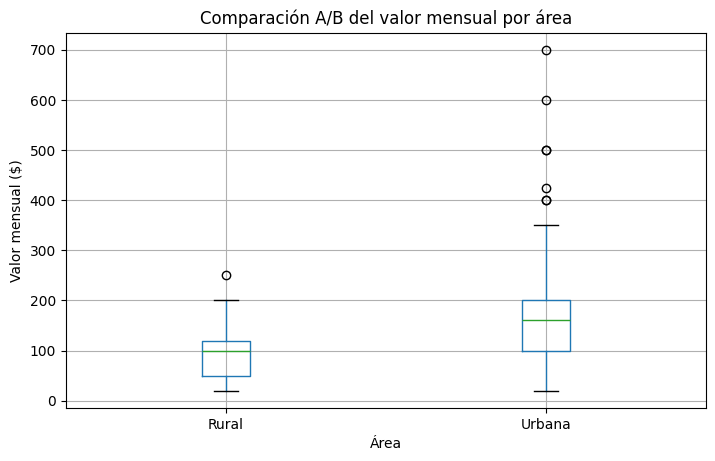

In [10]:
# Visualización A/B
fig, ax = plt.subplots(figsize=(8, 5))
loja.boxplot(column='vi141', by='area_etiqueta', ax=ax)
ax.set_title('Comparación A/B del valor mensual por área')
ax.set_xlabel('Área')
ax.set_ylabel('Valor mensual ($)')
plt.suptitle('')
plt.show()

## 8. APE10: ANOVA de un factor y prueba Post-Hoc de Tukey

Para el análisis multigrupo se usa como factor el número total de cuartos de la vivienda (**`vi06`**), agrupado en tres categorías:

- 1-2 cuartos.
- 3-4 cuartos.
- 5 o más cuartos.

La variable dependiente sigue siendo **`vi141`**.

### Hipótesis ANOVA

$$H_0: \mu_1 = \mu_2 = \mu_3$$

$$H_1: \text{al menos una media de grupo es diferente}$$

In [11]:
# ============================================================
# 9. ANOVA de un factor
# ============================================================

resumen_cuartos = loja.groupby('grupo_cuartos')['vi141'].agg(['count', 'mean', 'std', 'median'])
display(resumen_cuartos)

grupo_1 = loja.loc[loja['grupo_cuartos'] == '1-2 cuartos', 'vi141']
grupo_2 = loja.loc[loja['grupo_cuartos'] == '3-4 cuartos', 'vi141']
grupo_3 = loja.loc[loja['grupo_cuartos'] == '5 o más cuartos', 'vi141']

resultado_anova = f_oneway(grupo_1, grupo_2, grupo_3)

print(f'Estadístico F = {resultado_anova.statistic:.4f}')
print(f'Valor-p ANOVA = {resultado_anova.pvalue:.4e}')

if resultado_anova.pvalue < alpha:
    print('Decisión: se rechaza H0. Al menos una media difiere significativamente.')
else:
    print('Decisión: no se rechaza H0. No hay evidencia suficiente de diferencias entre grupos.')

,count,mean,std,median
grupo_cuartos,,,,
1-2 cuartos,71,81.4789,53.2742,70.0000
3-4 cuartos,193,150.7254,79.8289,150.0000
5 o más cuartos,38,217.1053,142.6754,190.0000


Estadístico F = 33.5994
Valor-p ANOVA = 6.8731e-14
Decisión: se rechaza H0. Al menos una media difiere significativamente.


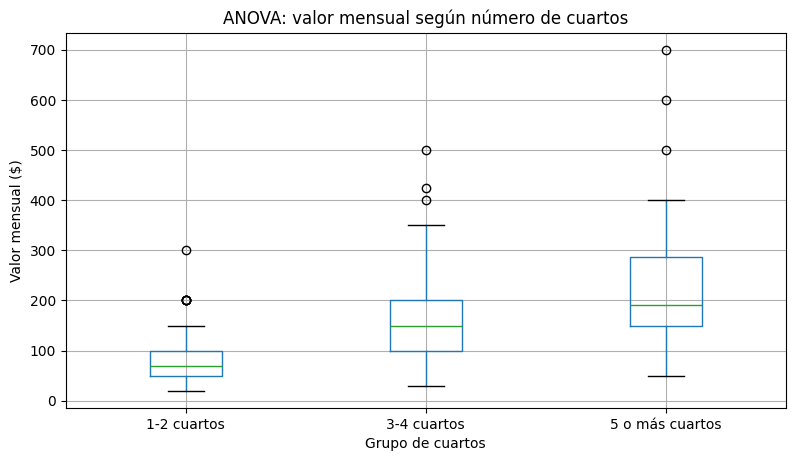

In [12]:
# Visualización ANOVA
fig, ax = plt.subplots(figsize=(9, 5))
loja.boxplot(column='vi141', by='grupo_cuartos', ax=ax)
ax.set_title('ANOVA: valor mensual según número de cuartos')
ax.set_xlabel('Grupo de cuartos')
ax.set_ylabel('Valor mensual ($)')
plt.suptitle('')
plt.show()

In [13]:
# ============================================================
# 10. Prueba Post-Hoc de Tukey
# ============================================================

resultado_tukey = pairwise_tukeyhsd(
    endog=loja['vi141'],
    groups=loja['grupo_cuartos'],
    alpha=0.05
)

print(resultado_tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
   group1        group2     meandiff p-adj  lower   upper   reject
------------------------------------------------------------------
1-2 cuartos     3-4 cuartos  69.2465   0.0 41.3596  97.1335   True
1-2 cuartos 5 o más cuartos 135.6264   0.0 95.2433 176.0095   True
3-4 cuartos 5 o más cuartos  66.3799   0.0 30.7231 102.0367   True
------------------------------------------------------------------


### Interpretación de Tukey

Como el ANOVA indica que existe diferencia significativa entre las medias, la prueba de Tukey permite identificar entre qué grupos ocurre la diferencia. Si en la columna **reject** aparece `True`, se concluye que ese par de grupos presenta diferencia estadísticamente significativa.

En este análisis, los grupos de vivienda con menor número de cuartos presentan un valor mensual promedio distinto frente a viviendas con más cuartos. Esto confirma que el tamaño físico de la vivienda se relaciona con el valor mensual de arriendo o gasto declarado.

## 9. Conclusiones generales

**C01.** La variable `vi141` de los hogares de Loja presenta una distribución sesgada hacia la derecha, con valores atípicos altos. El diagnóstico de normalidad advierte que los datos brutos no siguen una normal perfecta; sin embargo, el tamaño muestral permite aplicar inferencia sobre la media usando el respaldo del Teorema del Límite Central.

**C02.** El intervalo de confianza del 95% permite estimar el rango plausible del promedio poblacional del valor mensual de arriendo en Loja. Esta estimación es más informativa que una media aislada, porque incorpora incertidumbre muestral.

**C03.** La prueba T unimuestral rechaza la hipótesis de que el valor mensual promedio sea 200 dólares. Por lo tanto, el promedio observado en la muestra regional difiere de manera estadísticamente significativa de ese valor de referencia.

**C04.** La comparación A/B entre área urbana y rural muestra diferencias significativas, lo que indica que el contexto territorial influye en los valores de vivienda.

**C05.** El ANOVA de un factor demuestra diferencias significativas entre grupos definidos por número de cuartos. La prueba Post-Hoc de Tukey permite precisar los pares donde se concentran esas diferencias.

## 10. Referencias

- Walpole, R. E., Myers, R. H., Myers, S. L., & Ye, K. (2012). *Probabilidad y estadística para ingeniería y ciencias* (9.ª ed.). Pearson Educación.
- Devore, J. L. (2016). *Probabilidad y estadística para ingeniería y ciencias* (9.ª ed.). Cengage Learning.
- Conover, W. J. (1999). *Practical nonparametric statistics* (3.ª ed.). John Wiley & Sons.
- Instituto Nacional de Estadística y Censos. Base ENEMDU Vivienda y Hogar 2026-02.